In [1]:
# Import packages
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 250)
pd.set_option('display.max_rows', 250)

# The Energy Demand, Fuel Consumption and GHG Generation (EFG) Model (v0.6)

The EFG Module is predicated on the 'Emissions Estimation Model' methodology documented in Section 2.2 of the 4th IMO GHG Study, which includes the following steps:

<ol>
    <li>Operational Phase Assignment.</li>
    <li>Instantaneous power demands associated with main, auxiliiary and boiler engines per Operational Phase.</li>
    <li>Derivation of Instantaneous Fuel Consumption by Fuel Type</li>
    <li>Emissions generation.</li>
</ol>

The final sample output dataset is a combination of 'semi-synthetic' WindwardAI AIS data, Vessel Technical Specifications, Instantaneous Power Demand (as evaluated using the Admiralty Formula), hourly fuel consumption and associated emissions generation.

v0.6 features integration of the simplified Weather and Fouling Correction factors documented in Appendix L of the IMO 4th GHG Study, in a format that will enable their update with a more sophisticated methodology that utilises the Weather Data Fields provided by WindwardAI in future. Checks are performed for v0.6 against Section 2.2 and the Appendices of the IMO IV methodology.

Notebook issues and improvements to make:

<ul>
    <li>Checks against the content contained in the IMO IV model folder is left for v0.7.</li>
    <li>that the synthetic draught and speed values may exceed the reference values, and this is a little difficult to fix as these values are generated for the IMO number before joining with the vessel specifications dataset. This can ultimately lead to super high values of Main Engine Instantneous Power Demand and Main Engine Load Correction Factors far in exceedance of 1.0 (more than 13.0 in some cases). This is the case for all 'synthetic' data rows, however is likely to be drastically improved with real WindwardAI data.</li>
    <li>I think worth re-deriving 'Baseline' Specific Fuel Consumption values from primary fields of the Vessel Specifications dataset (specifically using Engine Code, Type, Tier and Fuel Type applied to Appendix B - Table 4). Can then remove 'me_sfoc', 'aux_sfoc' and 'boiler_sfoc' values as it's not clear where these come from. Exclude these fields from the initial Vessel Specifications dataset read-in, then can compare with the derivation based on Appendix B - Table 4.</li>
    <li>Also need to include amendments of Emissions Generation where Main Engines are loaded below 20%, as these engines are noted to operate with less combustion efficiency at lower loadings. Table 20 of the 4th IMO GHG Study presents low load adjustment factors where engine loads are evaluated to be 0 <= 2%, 2-10% and 10-20%.</li>
</ul>

<u><h5>1. Evaluation of Operational Phase</h5></u>

The 4th IMO GHG Study categorises a vessel's instantaneous activity into one of five Operational Phases: at berth, at anchor, maneuvering, in slow transit or at sea. The categorisation is based on the following features:

<ul>
    <li>Vessel Speed</li>
    <li>Main Engine Load</li>
    <li>Distance away from closest port (as contained in the UMAS ports dataset).</li>
    <li>Distance away from closest coastline (contained in shapefiles data sourced from Natural Earth).</li>
</ul>

<u><h5>2. Evaluation of Instantaneous Power Demand Associated with Main, Auxiliary and Boiler Engines</h5></u>

Evaluation of Main Engine Instantaneous Power Demand is undertaken using the version of the Admiralty Formula documented in the 4th IMO GHG Study, i.e. one that provides an estimate of Instantaneous Power in terms of Reference values of Power, Draught and Speed associated with a vessel (rather than the more vague 'Admiralty Coefficient').

<ol>
    <li>Reference Power, Reference Draught and Reference Speed from the Vessel Specification Dataset.</li>
    <li>Instantaneous Draught and Instantaneous Speed from AIS.</li>
</ol>

Table 17 of the 4th IMO GHG Study presents auxiliary and boiler engine power outputs depending on the vessel type bin, size bin and operational status of the vessel (i.e. whether at berth, anchored, manoeuvring or at sea). In addition, the following conditions are applied depending on whether the main engine power is estimated to be:
<ol>
    <li>between 0-150 kW, in which case both are set to 0 kW;</li>
    <li>between 150-500 kW, in which case the auxiliary engine is set at 5% of main engine power and the boiler is based on Table 17 values; and </li>
    <li>above 150 kW, in which case the engine and boiler values are based on Table 17.</li>
</ol>

<u><h5>3. Evaluation of Instantaneous Fuel Consumption</h5></u>

v0.6 then links Instantaneous Power Demand with Instantaneous Specific Fuel Consumption (g/kWh) by fuel type, for each engine and assuming compliance with SOx and NOx Emission Control Areas. 

In the case of the Main Engine, an expression utilising a Main Engine Load Correction Factor is applied. This parabolic relationship is stated to only be valid for propulsion systems that use internal combustion engines (examples of oil and LNG engines are given), whilst others (e.g. gas and steam turbine engines) are assumed not to be dependent on engine load, and the 'Baseline' Specific Fuel Consumption is always used. The Instantaneous Specific Fuel Consumption is then multiplied by the Instantaneous Power Demand to evaluate the total fuel consumed.

<u><h5>4. Evaluation of Instantaneous GHG Generation</h5></u>

Two types of Emission Factors are then introduced in order to derive the emissions associated with Instantaneous Fuel Consumption. 'Fuel-based' Emission Factors specify an amount of the pollutant per gram of fuel consumed, whilst 'Energy-based' Emission Factors specify an amount of the pollutant per unit (kWh) of energy demanded.

# 1. Energy Demand of the Main Engine (v0.6)

<h5><u>Background on Main Engine Operational Power Demand</u></h5>

To maintain a constant speed through water, a vessel must provide a propulsive force equal to its total resistive force. Whilst also impacted by Aerodynamic Resistance, R<sub>a</sub>, Total Resistance, R<sub>T</sub>, is dominated by Hydrodynamic Resistance, R<sub>h</sub> which is itself constistuted from the following:

<ul>
    <li><b>Frictional Resistance, R<sub>f</sub>,</b> relates to the resistance experienced by the hull as it interacts with the surrounding water. Frictional Resistance depends on factors such as the total hull area in contact with water (which can be proxied by vessel length), the state of the hull and the speed at which the vessel is travelling. Frictional Resistance typically accounts for up to 75% of the Total Resistance encountered by the vessel.</li>
    <li><b>Residual Resistance, R<sub>r</sub>,</b> is associated with changes in the streamlines of water as it interacts with the hull and the formation of waves as the vessel moves through the water.</li>
</ul>

Total Resistance is impacted heavily by weather conditions, principally owing to changes in Residual and Aerodynamic Resistance that result from changes in the speed, direction and frequency of waves and winds.

<h5><u>Derivation of the Admiralty Formula</u></h5>

Power represents the product of work done per unit of time, where work done evaluates to the product of force and distance. Therefore the theoretical instantaneous power, W<sub>i</sub>, required by a vessel to maintain a constant forward speed, v, can be given as:

W<sub>i</sub> = R<sub>T</sub> * v, where...

<ul>
    <li>W<sub>i</sub> is the Instantaneous Power required by the Vessel.</li>
    <li>R<sub>T</sub> is the total resistive force encountered by the vessel.</li>
    <li>v is the forward vessel speed (knots).</li>
</ul>

The 4th IMO GHG Study utilises a form of the Haversine Formula to express the Instantaneous Power of a vessel, W<sub>i</sub>, in terms of the 'Reference' Power, W<sub>ref</sub>, for the vessel (provided in the IHS dataset) scaled by instantaneous draught, t<sub>i</sub>, and speed, v<sub>i</sub>, values. The exponents representing the draught-power and speed-power relationships are the same as those provided in alternative expressions of the Admiralty Formula, namely powers of 2/3 and 3 respectively. 

The full expression for the Instantaneous Power required by the vessel utilised in the 4th IMO GHG Study, W<sub>i</sub>, is given by the following expression:

W<sub>i</sub> = δ<sub>w</sub> * W<sub>ref</sub> * (t<sub>i</sub> / t<sub>ref</sub>)<sup>2/3</sup> * (v<sub>i</sub> / v<sub>ref</sub>)<sup>3</sup> * (ή<sub>w</sub> * ή<sub>f</sub>)<sup>-1</sup>, where...

<ul>
    <li>W<sub>ref</sub> is the 'Reference' Power for the vessel (provided in the IHS Dataset utilised in IMO 4th GHG Study).</li>
    <li>t<sub>i</sub> is the Instantaneous Draught of the vessel (provided in AIS data).</li>
    <li>t<sub>ref</sub> is the Reference Draught of the vessel (provided in the IHS Dataset utilised in IMO 4th GHG Study).</li>
    <li>v<sub>i</sub> is the Instantaneous Speed of the vessel (provided in AIS data).</li>
    <li>v<sub>ref</sub> is the Reference Speed of the vessel (provided in the IHS Dataset utilised in IMO 4th GHG Study).</li>
    <li>ή<sub>w</sub> is the Weather Correction Factor. In continuity with the Third IMO GHG Study, it's assumed that weather effect result in 15% of additional power being required for 'ocean-going' vessels (defined as vessels operating at more than 5nm from the shore), whilst an additional 10% is assumed for coastal activity (defined as less than 5 nm from shore).</li>
    <li>ή<sub>f</sub> is the Fouling Correction Factor. The approach to accounting for hull fouling is continued from the 3rd IMO GHG Study, namely applying a flat 9% penalty in the form of a correction factor to reflect the impact of hull fouling.</li>
</ul>

δ<sub>w</sub> is the Speed-Power Correction Factor. The 'Reference Speed' is provided in the IHS Vessel Specification dataset (utilised in the 4th IMO GHG Study) and represents the 'maximum vessel speed in knots when the engines are running at Maximum Continuous Rating (MCR)'. However, the authors note that some classes of recent newbuilds are equipped with more powerful engines to enable greater maximum speeds, yet aren't actually designed to operate at such speeds regularly. After comparison with MRV data, the authors suggest that the IHS 'Speed' value associated with large Containerships and Cruise vessels may relate to the vessel's intended 'Service Speed' rather than the speed at MCR (associated with around 75% rather than 100% MCR), and so δ<sub>w</sub> is set at 0.75 in these cases.

<h5><u>Final Form of the Admiralty Formula Taken Forward</u></h5>

It's suggested not to consider the impacts of weather, hull fouling or speed-power correction for the early versions of the EFG model being developed in this research. In addition, it's assumed that vessel usage patterns can be approximated by the behaviour of the main engine alone, and that the datasets we will be able to source will have the same data fields as those utilised in the 4th IMO GHG Study. 

Therefore the final version of the Admiralty Formula to be implemented is as follows:

W<sub>i</sub> = W<sub>ref</sub> * (t<sub>i</sub> / t<sub>ref</sub>)<sup>2/3</sup> * (v<sub>i</sub> / v<sub>ref</sub>)<sup>3</sup>, where...

<ul>
    <li>W<sub>ref</sub> is the 'Reference' Power for the vessel (assumed to be the 'eng_total_kw' field provided in the IHS Dataset utilised in IMO 4th GHG Study).</li>
    <li>t<sub>i</sub> is the Instantaneous Draught of the vessel (assumed to be the 'reported_draught' field provided in the WindwardAI AIS dataset).</li>
    <li>t<sub>ref</sub> is the Reference Draught of the vessel (assumed to be the 'draught' field provided in the IHS Dataset utilised in IMO 4th GHG Study).</li>
    <li>v<sub>i</sub> is the Instantaneous Speed of the vessel (assumed to be the 'sog' field provided in the WindwardAI AIS dataset).</li>
    <li>v<sub>ref</sub> is the Reference Speed of the vessel (assumed to be the 'service_speed' field provided in the IHS Dataset utilised in IMO 4th GHG Study).</li>
</ul>

In [2]:
ais_test_cols = {"imo":int, "lon":"float", "lat":"float", "distance_to_shore":"float", "reported_draught":"float", "sog":"float", "cog":"float"}
ais_test = pd.read_csv("/Users/apple/repos/AISenv/datasets/ais_test/ais_test_v0.3.csv", dtype=ais_test_cols)
ais_test["ts"] = ais_test["ts"].astype({"ts":"datetime64[ns]"})
display(ais_test.iloc[:2])

vessels_test_cols = {
    "imo":"int", "mmsi":"float", "type_bin":"int", "size_bin":"int", "year_of_built":"int", "gross_tonnage":"float", "deadweight":"float", 
    "draught":"float", "service_speed":"float", "main_engine_rpm":"float", "eng_total_kw":"float", "engine_code":"int", "tier":"int",
    "me_sfoc":"float", "aux_sfoc":"float", "boiler_sfoc":"float", "aux_at_berth":"float", "aux_anchor":"float", "aux_manoeuvring":"float", "aux_slow":"float", "aux_sea":"float"
}
vessels_test = pd.read_csv("/Users/apple/repos/AISenv/datasets/vessels_test/vessels_test_v0.3.csv", dtype=vessels_test_cols)
display(vessels_test.iloc[:2])

ais_vessels_test = pd.merge(ais_test, vessels_test, left_on="imo", right_on="imo", how="left")
display(ais_vessels_test.iloc[:2])

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port
0,9120841,2022-07-15 01:00:00,-123.31067,-17.27125,452.041,11.4,17.200089,292.341333,603.084122
1,9120841,2022-07-15 02:00:00,-123.55103,-17.07835,461.247,11.4,18.006734,308.748652,603.999555


,imo,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc
0,1740906,NaN,WASANA NO. 388,17,Miscellaneous - fishing,1,0-+,Sri Lanka,2002,79.0,94.613503,3,HSD,1,1386.046364,1300.0,3.4,13.038292,4,4,4,185.0,185.0,320.0
1,2560298,357593000.0,CHUNG KUO NO. 22,17,Miscellaneous - fishing,1,0-+,Panama,1999,66.0,56.691748,2,MSD,0,1386.046364,750.0,3.4,13.038292,4,4,4,185.0,190.0,320.0


,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc
0,9120841,2022-07-15 01:00:00,-123.31067,-17.27125,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0
1,9120841,2022-07-15 02:00:00,-123.55103,-17.07835,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0


<u><h5>Weather and Fouling Correction Factors</h5></u>

v0.6 makes use of the Weather and Fouling correction factors applied and documented in the 4th IMO GHG Study. Weather Correction factors amounted to 15% of Energy Demand (evaluated using the Haversine formula) for 'Ocean-going' vessel activity (defined as activity greater than 5 nm from shore) and 10% for coastal vessel activity (defined as activity less than 5 nm from shore). The Weather and Fouling Correction factors applied in the 4th IMO GHG Study are presented in Appendix L, and demonstrate a constant application in the case of Fouling. For Weather correction, the 15% (0.867) factor is observed to be applied in virtually all cases except for the smallest vessel classes. For Fouling, a 9% (0.917) factor is observed to be applied in all cases.

Whilst the paragraph on Page 64 indicates that the same values are used for all vessels, the table presented in Appendix L instead provides differentiated Weather Correction factors depending on Vessel Class. Since it isn't clear which of these methods is applied, this notebook assumes the simpler approach of applying the values presented in Table 44 of Appendix L. Unless evidence is found in the IMO GHG Study IV FUSE folder that the other method was used, this simplified method will be used for the moment.

<u><h5>Accounting for Edge Cases</h5></u>

In-line with final review against the written IMO methodology, a Corrected Instantaneous Draft field is introduced to ensure that the Instantaneous Draft of a vessel cannot exceed its Reference Draft.

An expression to provide corrected instantaneous vessel speed is provided based on the assumption that the vessel speed shouldn't exceed 1.5x the vessel's Reference Speed (the 'service_speed' field), however this is currently commented out as this condition doesn't make much sense, and there is also the subsequent Power Correction which is used to ensure dubious Instantaneous Power values aren't carried forward.

Instead, the 4th IMO GHG Study says the following with respect to Main Engine powering:

<i>"In some cases, the estimated main engine load factor can be greater than 100% MCR, implying that a ship is using more than its installed main engine power, which is not possible. To avoid this, the bottom-up model removes SOG readings that are 1.5 times larger than the design speed, replacing it with maximum speed. In the particular case where, after applying the hull, weather, draught, and speed-power adjustment factors, the main engine load factor is still above 100% MCR, then the bottom-up model assigns to this case a load factor of 98% MCR."</i>

For 'v0.6', a corrected Instantaneous Vessel Power value is provided in order to limit the vessel power to 0.98 MCR. 

In [3]:
# Setting up the data fields required for the Admiralty Formula
ais_vessels_test["t_ref"] = ais_vessels_test.draught            # Representing 'Reference Draught' in the Admiralty Formula
ais_vessels_test["t_i"] = ais_vessels_test.reported_draught     # Representing 'Instantaneous Draught' in the Admiralty Formula
ais_vessels_test["t_i_c"] = np.where(ais_vessels_test.t_i > ais_vessels_test.t_ref, ais_vessels_test.t_ref, ais_vessels_test.t_i) # Correct Instantaneous Draft to be less than equal to the Reference Draft 
ais_vessels_test["v_ref"] = ais_vessels_test.service_speed      # Representing 'Reference Speed' in the Admiralty Formula - Confirmed in IMO IV
ais_vessels_test["v_i"] = ais_vessels_test.sog                  # Representing 'Instantaneous Speed' in the Admiralty Formula
ais_vessels_test["w_me_ref_kw"] = ais_vessels_test.eng_total_kw # Representing 'Reference Power' in the Admiralty Formula
ais_vessels_test.iloc[:2]

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc,t_ref,t_i,v_ref,v_i,w_me_ref_kw
0,9120841,2022-07-15 01:00:00,-123.31067,-17.27125,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.200089,54840.0
1,9120841,2022-07-15 02:00:00,-123.55103,-17.07835,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,18.006734,54840.0


In [4]:
# Energy Demand of the Auxiliary and Boiler Engines
weather_fouling_cf_cols = ["type_bin", "size_bin", "c_w", "c_f"]
weather_fouling_cf_d = {"c_w":"float", "c_f":"float"}
weather_fouling_cf = pd.read_csv("/Users/apple/repos/AISenv/EFG Module/weather_fouling/weather_fouling_v0.1.csv", usecols=weather_fouling_cf_cols, dtype=weather_fouling_cf_d)
ais_vessels_test = pd.merge(ais_vessels_test, weather_fouling_cf, left_on=["type_bin", "size_bin"], right_on=["type_bin", "size_bin"], how="left")

# Evaluate Instantaneous Power (kW) using the Admiralty Formula
ais_vessels_test["w_me_i_kw"] = ais_vessels_test.w_me_ref_kw * ((ais_vessels_test.t_i_c / ais_vessels_test.t_ref) ** (2.0 / 3.0)) * ((ais_vessels_test.v_i / ais_vessels_test.v_ref) ** 3.0)
ais_vessels_test["w_me_i_wf_kw"] = ais_vessels_test.w_me_i_kw / (ais_vessels_test.c_w * ais_vessels_test.c_f)
ais_vessels_test["w_me_i_wf_c_kw"] = np.where(ais_vessels_test.w_me_i_wf_kw > 0.98 * ais_vessels_test.w_me_ref_kw, 0.98 * ais_vessels_test.w_me_ref_kw, ais_vessels_test.w_me_i_wf_kw)

# Evaluate Instantaneous Average Load of the Main Engine Compared to its Reference Value
ais_vessels_test["w_me_load"] = ais_vessels_test.w_me_i_wf_kw / ais_vessels_test.w_me_ref_kw
ais_vessels_test["w_me_load_c"] = ais_vessels_test.w_me_i_wf_c_kw / ais_vessels_test.w_me_ref_kw
ais_vessels_test.iloc[:2]

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc,t_ref,t_i,v_ref,v_i,w_me_ref_kw,c_w,c_f,w_me_i_kw,w_me_i_wf_kw,w_me_i_wf_c_kw,w_me_load,w_me_load_c
0,9120841,2022-07-15 01:00:00,-123.31067,-17.27125,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.200089,54840.0,0.867,0.917,12773.188853,16066.116068,16066.116068,0.292963,0.292963
1,9120841,2022-07-15 02:00:00,-123.55103,-17.07835,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,18.006734,54840.0,0.867,0.917,14655.886331,18434.172828,18434.172828,0.336145,0.336145


# 2. Evaluation of Operational Mode

Assumed to be 'At sea', unless one of the other qualifying criteria is met. Note, the condition put in-place for Tankers in the 4th IMO GHG Study (specifically where tankers are between 1-5 nm from port) isn't included here, for the moment.

The 4th IMO GHG Study states that a vessel is defined as operating in one of five phases, however the phase 'Slow transit' is not included in the Operational Mode disaggregation for evaluation of Auxiliary and Boiler Engine power output (Table 17). Based on the breakdown presented in Table 16, it's assumed that 'Slow transit' is incorporated into the 'Normal cruising' operational mode. 

In [5]:
## Evaluation of Operational Mode
ais_vessels_test["op_mode"] = "Cruising"

# When vessel speed is less than 1 nm ('Anchored', unless close to port in which case 'At berth')
ais_vessels_test.loc[(ais_vessels_test.sog <= 1.0), "op_mode"] = "Anchored"
ais_vessels_test.loc[(ais_vessels_test.sog <= 1.0) & (ais_vessels_test.distance_to_port <= 1.0), "op_mode"] = "At berth"

# When vessel speed is between 1 to 3 nm ('Anchored')
ais_vessels_test.loc[(ais_vessels_test.sog > 1.0) & (ais_vessels_test.sog <= 3.0), "op_mode"] = "Anchored"

# When vessel speed is between 3 to 5 nm ('Manoeuvering')
ais_vessels_test.loc[(ais_vessels_test.sog > 3.0) & (ais_vessels_test.sog <= 5.0), "op_mode"] = "Manoeuvering"
ais_vessels_test.loc[(ais_vessels_test.sog > 3.0) & (ais_vessels_test.sog <= 5.0) & (ais_vessels_test.distance_to_shore >= 5.0) & (ais_vessels_test.w_me_load_c <= 0.65), "op_mode"] = "Slow transit"
ais_vessels_test.loc[(ais_vessels_test.sog > 3.0) & (ais_vessels_test.sog <= 5.0) & (ais_vessels_test.distance_to_shore >= 5.0) & (ais_vessels_test.w_me_load_c > 0.65), "op_mode"] = "Cruising"

# When vessel speed is greater 5 nm ('Cruising' is engine load is greater than 0.65, 'Slow transit' if less than 0.65, 'Maneouvering' is distance to port is less than 1.0 nm)
ais_vessels_test.loc[(ais_vessels_test.sog > 5.0), "op_mode"] = "Cruising"
ais_vessels_test.loc[(ais_vessels_test.sog > 5.0) & (ais_vessels_test.w_me_load_c <= 0.65), "op_mode"] = "Slow transit"
ais_vessels_test.loc[(ais_vessels_test.sog > 5.0) & (ais_vessels_test.distance_to_port <= 1.0), "op_mode"] = "Manoeuvering"
ais_vessels_test.head()

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc,t_ref,t_i,v_ref,v_i,w_me_ref_kw,c_w,c_f,w_me_i_kw,w_me_i_wf_kw,w_me_i_wf_c_kw,w_me_load,w_me_load_c,op_mode
0,9120841,2022-07-15 01:00:00,-123.310670,-17.271250,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.200089,54840.0,0.867,0.917,12773.188853,16066.116068,16066.116068,0.292963,0.292963,Slow transit
1,9120841,2022-07-15 02:00:00,-123.551030,-17.078350,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,18.006734,54840.0,0.867,0.917,14655.886331,18434.172828,18434.172828,0.336145,0.336145,Slow transit
2,9120841,2022-07-15 03:00:00,-123.790924,-16.887999,470.791,11.4,17.898995,308.431284,605.303102,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.898995,54840.0,0.867,0.917,14394.386731,18105.258649,18105.258649,0.330147,0.330147,Slow transit
3,9120841,2022-07-15 04:00:00,-124.082850,-16.812803,473.650,11.4,17.371791,284.444577,599.673191,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.371791,54840.0,0.867,0.917,13159.549593,16552.080581,16552.080581,0.301825,0.301825,Slow transit
4,9120841,2022-07-15 05:00:00,-124.385500,-16.790445,473.898,11.4,17.447278,274.225000,591.444109,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.447278,54840.0,0.867,0.917,13331.845918,16768.794887,16768.794887,0.305777,0.305777,Slow transit


# 3. Evaluation of Fuel Consumption

## 3.1 Main Engine Fuel Consumption

The 4th IMO GHG Study evaluates the Instantaneous Specific Fuel Consumption of the Main Engine, SFC<sub>ME, i</sub>, using an expression that modifies a 'Baseline' value of Specific Fuel Consumption.

SFC<sub>ME, i</sub> = SFC<sub>ME, base</sub> * CF<sub>L</sub>

The 'Baseline' value of Specific Fuel Consuption refers to the most efficient point of the engine along it's fuel consumption-loading curve (in grams of fuel consumed per kWh of mechanical energy output, g/kWh), and is typically located at around 75-80% of the engine's Maximum Continuous Rating (average loading). The 'Baseline' value of Specific Fuel Consuption therefore represents a minimum value, and the Main Engine Load Correction Factor, CF<sub>L</sub>, will always be larger than or equal to one. The 3rd IMO GHG Study combined several SFC curves to produce an empirical expression for the Main Engine Load Correction Factor, CF<sub>L</sub>, which is given as:

CF<sub>L</sub> = 0.455 * (Load<sub>i</sub> / Load<sub>max</sub>)<sup>2</sup> - 0.710 * (Load<sub>i</sub> / Load<sub>max</sub>) + 1.280

<Axes: xlabel='Average Load'>

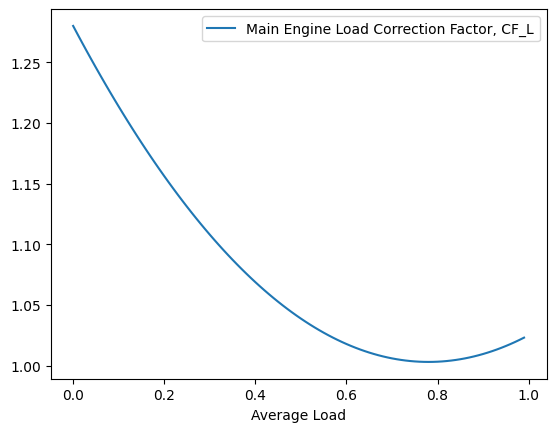

In [6]:
cf_l_x = np.arange(0.0, 1.0, 0.01)
cf_l_y = lambda w_me_load : 0.455 * w_me_load ** 2.0 - 0.710 * w_me_load + 1.280
test_df_data = {'Average Load': cf_l_x, 'Main Engine Load Correction Factor, CF_L': cf_l_y(cf_l_x)}
test_df = pd.DataFrame(data=test_df_data)
test_df.plot(x="Average Load", y="Main Engine Load Correction Factor, CF_L")

<h5><u>Final Form of the Specific Fuel Consumption Equation Taken Forward</u></h5>

The Main Engine Load Correction Factor, CF<sub>L</sub>, derived in the 3rd IMO GHG Study (and taken forward into the 4th IMO GHG Study) is utilised for the purposes of this research. The final expression to represent Instantaneous Specific Fuel Consumption of the Main Engine, SFC<sub>ME, i</sub>, is therefore:

SFC<sub>ME, i</sub> = SFC<sub>ME, base</sub> * (0.455 * (Load<sub>i</sub> / Load<sub>max</sub>)<sup>2</sup> - 0.710 * (Load<sub>i</sub> / Load<sub>max</sub>) + 1.280), where...

<ul>
    <li>SFC<sub>ME, i</sub> is the Instantaneous Specific Fuel Consumption of the Main Engine (g/kWh).</li>
    <li>SFC<sub>ME, base</sub> is the Baseline Specific Fuel Consumption of the Main Engine (g/kWh) (taken from the 'me_sfoc' field provided in the IHS Dataset utilised in IMO 4th GHG Study, which seems to align well with Table 19 of IMO 4th GHG Study).</li>
    <li>Load<sub>i</sub> the average instantaneous Mechanical Shaft Power (kW), P (derived via the Admiralty Formula above).</li>
    <li>Load<sub>max</sub> is the maximum Mechanical Shaft Power (kW), P (assumed equal to the 'Reference' Power for the vessel, W<sub>ref</sub>, and the 'eng_total_kw' field provided in the IHS Dataset).</li>
</ul>

In [7]:
# Set up data fields required for the evaluation of Instantaneous Specific Fuel Consumption in g/kWh
ais_vessels_test["sfc_me_base_g_per_kWh"] = ais_vessels_test.me_sfoc # REPLACE with value based on Appendix B !!
#ais_vessels_test["sfc_aux_base_g_per_kWh"] = 
#ais_vessels_test["sfc_boi_base_g_per_kWh"] = 
#ais_vessels_test["w_me_load_c"] = ais_vessels_test.eng_total_kw # Representing 'Maxiumum Mechanical Shaft Power' in the expression for Instantaneous Specific Fuel Consumption

# Evaluate the Instantaneous Specific Fuel Consumption, g/kWh
ais_vessels_test["cf_l"] = 0.455 * ais_vessels_test.w_me_load_c ** 2.0 - 0.710 * ais_vessels_test.w_me_load_c + 1.280
ais_vessels_test["sfc_me_i_g_per_kWh"] = ais_vessels_test.sfc_me_base_g_per_kWh * ais_vessels_test.cf_l

# Evaluate the Instantaneous Fuel Consumption, g/h
ais_vessels_test["fc_me_i_g"] = ais_vessels_test.sfc_me_i_g_per_kWh * ais_vessels_test.w_me_i_wf_c_kw
ais_vessels_test.iloc[:2]

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc,t_ref,t_i,v_ref,v_i,w_me_ref_kw,c_w,c_f,w_me_i_kw,w_me_i_wf_kw,w_me_i_wf_c_kw,w_me_load,w_me_load_c,op_mode,sfc_me_base_g_per_kWh,cf_l,sfc_me_i_g_per_kWh,fc_me_i_g
0,9120841,2022-07-15 01:00:00,-123.31067,-17.27125,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.200089,54840.0,0.867,0.917,12773.188853,16066.116068,16066.116068,0.292963,0.292963,Slow transit,185.0,1.111047,205.543787,3.302290e+06
1,9120841,2022-07-15 02:00:00,-123.55103,-17.07835,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,18.006734,54840.0,0.867,0.917,14655.886331,18434.172828,18434.172828,0.336145,0.336145,Slow transit,185.0,1.092749,202.158605,3.726627e+06


## 3.2 Auxiliary and Boiler Engine Fuel Consumption

The 4th IMO GHG Study evaluates fuel consumption of Auxiliary and Boiler engines using the same method of multiplying a Specific Fuel Consumption with estimated instantaneous power demand. Unlike the Main Engine, the 4th IMO GHG Study assumes that the Specific Fuel Consumption associated with Auxiliary and Boiler engines does not vary with load, and therefore a single scaling factor for each is simply multiplied by the estimated Instantaneous Power Demand of each engine. Flat Specific Fuel Consumption estimates for Auxiliary and Boiler engines are provided in Table 19 of the GHG Study, broken down by input Fuel Type (HFO, MDO or LNG) and Year of Build (pre-1983, 1984-2000 or 2001+). Here, it is assumed that the Build Year field of Vessel Specifications dataset ('year_of_built') also represents the build year of the vessel's engine, however this may not be true. 

On exploration, it appears that 'me_sfoc', 'aux_sfoc' and 'boiler_sfoc' fields present in the Vessel Specifications database align well with 'Base' Specific Fuel Consumption values (g/kWh) provided in Table 19 of the 4th IMO GHG Study. This therefore gives confidence that each of these fields can be used to evaluate fuel consumption for each engine with incorporation of the Power Output of the relevant engine.

In [8]:
# Energy Demand of the Auxiliary and Boiler Engines
aux_boiler_power_output_cols = ["type_bin", "size_bin", "op_mode", "aux_power_kw", "boiler_power_kw"]
aux_boiler_power_output_d = {"aux_power_kw":"float", "boiler_power_kw":"float"}
aux_boiler_power_output_r = {"aux_power_kw":"w_aux_i_kw", "boiler_power_kw":"w_boi_i_kw"}
aux_boiler_power_output = pd.read_csv("/Users/apple/repos/AISenv/EFG Module/aux_boiler_power_output/aux_boiler_power_output_v0.2.csv", usecols=aux_boiler_power_output_cols, dtype=aux_boiler_power_output_d).rename(columns=aux_boiler_power_output_r)
ais_vessels_test = pd.merge(ais_vessels_test, aux_boiler_power_output, left_on=["type_bin", "size_bin", "op_mode"], right_on=["type_bin", "size_bin", "op_mode"], how="left")
ais_vessels_test["fc_aux_i_g"] = ais_vessels_test.aux_sfoc * ais_vessels_test.w_aux_i_kw # ais_vessels_test.sfc_aux_base_g_per_kWh * ais_vessels_test.w_aux_i_kw
ais_vessels_test["fc_boi_i_g"] = ais_vessels_test.boiler_sfoc * ais_vessels_test.w_boi_i_kw # ais_vessels_test.sfc_boi_base_g_per_kWh * ais_vessels_test.w_boi_i_kw
ais_vessels_test.head()

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc,t_ref,t_i,v_ref,v_i,w_me_ref_kw,c_w,c_f,w_me_i_kw,w_me_i_wf_kw,w_me_i_wf_c_kw,w_me_load,w_me_load_c,op_mode,sfc_me_base_g_per_kWh,cf_l,sfc_me_i_g_per_kWh,fc_me_i_g,w_aux_i_kw,w_boi_i_kw,fc_aux_i_g,fc_boi_i_g
0,9120841,2022-07-15 01:00:00,-123.310670,-17.271250,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.200089,54840.0,0.867,0.917,12773.188853,16066.116068,16066.116068,0.292963,0.292963,Slow transit,185.0,1.111047,205.543787,3.302290e+06,0.0,1800.0,0.0,612000.0
1,9120841,2022-07-15 02:00:00,-123.551030,-17.078350,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,18.006734,54840.0,0.867,0.917,14655.886331,18434.172828,18434.172828,0.336145,0.336145,Slow transit,185.0,1.092749,202.158605,3.726627e+06,0.0,1800.0,0.0,612000.0
2,9120841,2022-07-15 03:00:00,-123.790924,-16.887999,470.791,11.4,17.898995,308.431284,605.303102,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.898995,54840.0,0.867,0.917,14394.386731,18105.258649,18105.258649,0.330147,0.330147,Slow transit,185.0,1.095189,202.610021,3.668307e+06,0.0,1800.0,0.0,612000.0
3,9120841,2022-07-15 04:00:00,-124.082850,-16.812803,473.650,11.4,17.371791,284.444577,599.673191,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.371791,54840.0,0.867,0.917,13159.549593,16552.080581,16552.080581,0.301825,0.301825,Slow transit,185.0,1.107154,204.823492,3.390255e+06,0.0,1800.0,0.0,612000.0
4,9120841,2022-07-15 05:00:00,-124.385500,-16.790445,473.898,11.4,17.447278,274.225000,591.444109,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.447278,54840.0,0.867,0.917,13331.845918,16768.794887,16768.794887,0.305777,0.305777,Slow transit,185.0,1.105441,204.506541,3.429328e+06,0.0,1800.0,0.0,612000.0


# 4. Emissions Generations

'efg_v0.6' implements a simplified version of the Emission Factors methodology featured in the 4th IMO GHG Study. The Emission Factors applied can take the form of two types depending on the specific emission species considered:

<ol>
    <li>EM<sub>i</sub> = EF<sub>e</sub> . W<sub>i</sub>   Mass of emission per kilowatt-hour of engine output power, g / kWh; or</li>
    <li>EM<sub>i</sub> = FC<sub>i</sub> . EF<sub>f</sub>   Mass of emission per gram of fuel consumed, g / g.</li>
</ol>

Instead of assigning bespoke Emission Factors per engine type AND fuel type as is done in the 4th IMO GHG Study (see Appendix B - Table 4), this methodology currently just applies simplified Emission Factors per major Fuel Type:

<ul>
    <li>1 - HFO, using MDO in SECAs.</li>
    <li>4 - MDO.</li>
    <li>5 - LNG for Main Engine, then HFO (20% overall) or MDO (30% overall) for Auxiliary and Boiler Engines.</li>
    <li>6 - Methanol for Main Engine, then HFO (15% overall) or MDO (15% overall) for Auxiliary and Boiler Engines.</li>
</ul>

This is reasonable assumption in most cases, except in certain instances such as Methane (slip) emissions where emission factors can vary from 0.2 - 5.5 g/kWh depending on the engine type.

In [9]:
fuel_emissions = pd.read_csv("/Users/apple/repos/AISenv/EFG Module/engine_fuel_codes_emissions/fuel_emissions_v0.1.csv")
display(fuel_emissions)

# Main Engine
me_r = {"fuel_code":"me_fuel", "g_CO2_per_g_fuel":"co2_me_g_per_gfuel", "g_CH4_per_kWh":"ch4_me_g_per_kWh", "g_N2O_per_kWh":"n2o_me_g_per_kWh"}
me_fuel_emissions = fuel_emissions.drop(columns="fuel").copy().rename(columns=me_r)
#display(me_fuel_emissions)

# Auxiliary Engine
aux_r = {"fuel_code":"aux_fuel", "g_CO2_per_g_fuel":"co2_aux_g_per_gfuel", "g_CH4_per_kWh":"ch4_aux_g_per_kWh", "g_N2O_per_kWh":"n2o_aux_g_per_kWh"}
aux_fuel_emissions = fuel_emissions.drop(columns="fuel").copy().rename(columns=aux_r)
#display(aux_fuel_emissions)

# Boiler Engine
boiler_r = {"fuel_code":"boiler_fuel", "g_CO2_per_g_fuel":"co2_boi_g_per_gfuel", "g_CH4_per_kWh":"ch4_boi_g_per_kWh", "g_N2O_per_kWh":"n2o_boi_g_per_kWh"}
boiler_fuel_emissions = fuel_emissions.drop(columns="fuel").copy().rename(columns=boiler_r)
#display(boiler_fuel_emissions)

,fuel_code,fuel,g_CO2_per_g_fuel,g_CH4_per_kWh,g_N2O_per_kWh
0,1,HFO,3.114,0.01,0.030
1,4,MDO,3.206,0.01,0.030
2,5,LNG,2.750,2.50,0.020
3,6,Methanol,1.375,0.01,0.003


In [10]:
ais_vessels_test_G_temp_1 = pd.merge(ais_vessels_test, me_fuel_emissions, left_on="me_fuel", right_on="me_fuel", how="left")
ais_vessels_test_G_temp_2 = pd.merge(ais_vessels_test_G_temp_1, aux_fuel_emissions, left_on="aux_fuel", right_on="aux_fuel", how="left")
ais_vessels_test_G = pd.merge(ais_vessels_test_G_temp_2, boiler_fuel_emissions, left_on="boiler_fuel", right_on="boiler_fuel", how="left")

# Main Engine Emissions Generation
ais_vessels_test_G["co2_me_g"] = ais_vessels_test_G.fc_me_i_g * ais_vessels_test_G.co2_me_g_per_gfuel
ais_vessels_test_G["ch4_me_g"] = ais_vessels_test_G.w_me_i_wf_c_kw * ais_vessels_test_G.ch4_me_g_per_kWh
ais_vessels_test_G["n2o_me_g"] = ais_vessels_test_G.w_me_i_wf_c_kw * ais_vessels_test_G.n2o_me_g_per_kWh

# Auxiliary Engine Emissions Generation
ais_vessels_test_G["co2_aux_g"] = ais_vessels_test_G.fc_aux_i_g * ais_vessels_test_G.co2_aux_g_per_gfuel
ais_vessels_test_G["ch4_aux_g"] = ais_vessels_test_G.w_aux_i_kw * ais_vessels_test_G.ch4_aux_g_per_kWh
ais_vessels_test_G["n2o_aux_g"] = ais_vessels_test_G.w_aux_i_kw * ais_vessels_test_G.n2o_aux_g_per_kWh

# Boiler Engine Emissions Generation
ais_vessels_test_G["co2_boi_g"] = ais_vessels_test_G.fc_boi_i_g * ais_vessels_test_G.co2_boi_g_per_gfuel
ais_vessels_test_G["ch4_boi_g"] = ais_vessels_test_G.w_boi_i_kw * ais_vessels_test_G.ch4_boi_g_per_kWh
ais_vessels_test_G["n2o_boi_g"] = ais_vessels_test_G.w_boi_i_kw * ais_vessels_test_G.n2o_boi_g_per_kWh

# Output to Folder
ais_vessels_test_G.to_csv("/Users/apple/repos/AISenv/EFG Module/efg_v0.6.csv", index=False)
ais_vessels_test_G.head()

,imo,ts,lon,lat,distance_to_shore,reported_draught,sog,cog,distance_to_port,mmsi,vessel_name,type_bin,ship_type_standardized,size_bin,size_range_standardized,flag,year_of_built,gross_tonnage,deadweight,engine_code,engine_type,tier,eng_total_kw,main_engine_rpm,draught,service_speed,me_fuel,aux_fuel,boiler_fuel,me_sfoc,aux_sfoc,boiler_sfoc,t_ref,t_i,v_ref,v_i,w_me_ref_kw,c_w,c_f,w_me_i_kw,w_me_i_wf_kw,w_me_i_wf_c_kw,w_me_load,w_me_load_c,op_mode,sfc_me_base_g_per_kWh,cf_l,sfc_me_i_g_per_kWh,fc_me_i_g,w_aux_i_kw,w_boi_i_kw,fc_aux_i_g,fc_boi_i_g,co2_me_g_per_gfuel,ch4_me_g_per_kWh,n2o_me_g_per_kWh,co2_aux_g_per_gfuel,ch4_aux_g_per_kWh,n2o_aux_g_per_kWh,co2_boi_g_per_gfuel,ch4_boi_g_per_kWh,n2o_boi_g_per_kWh,co2_me_g,ch4_me_g,n2o_me_g,co2_aux_g,ch4_aux_g,n2o_aux_g,co2_boi_g,ch4_boi_g,n2o_boi_g
0,9120841,2022-07-15 01:00:00,-123.310670,-17.271250,452.041,11.4,17.200089,292.341333,603.084122,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.200089,54840.0,0.867,0.917,12773.188853,16066.116068,16066.116068,0.292963,0.292963,Slow transit,185.0,1.111047,205.543787,3.302290e+06,0.0,1800.0,0.0,612000.0,3.114,0.01,0.03,3.114,0.01,0.03,3.114,0.01,0.03,1.028333e+07,160.661161,481.983482,0.0,0.0,0.0,1905768.0,18.0,54.0
1,9120841,2022-07-15 02:00:00,-123.551030,-17.078350,461.247,11.4,18.006734,308.748652,603.999555,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,18.006734,54840.0,0.867,0.917,14655.886331,18434.172828,18434.172828,0.336145,0.336145,Slow transit,185.0,1.092749,202.158605,3.726627e+06,0.0,1800.0,0.0,612000.0,3.114,0.01,0.03,3.114,0.01,0.03,3.114,0.01,0.03,1.160472e+07,184.341728,553.025185,0.0,0.0,0.0,1905768.0,18.0,54.0
2,9120841,2022-07-15 03:00:00,-123.790924,-16.887999,470.791,11.4,17.898995,308.431284,605.303102,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.898995,54840.0,0.867,0.917,14394.386731,18105.258649,18105.258649,0.330147,0.330147,Slow transit,185.0,1.095189,202.610021,3.668307e+06,0.0,1800.0,0.0,612000.0,3.114,0.01,0.03,3.114,0.01,0.03,3.114,0.01,0.03,1.142311e+07,181.052586,543.157759,0.0,0.0,0.0,1905768.0,18.0,54.0
3,9120841,2022-07-15 04:00:00,-124.082850,-16.812803,473.650,11.4,17.371791,284.444577,599.673191,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.371791,54840.0,0.867,0.917,13159.549593,16552.080581,16552.080581,0.301825,0.301825,Slow transit,185.0,1.107154,204.823492,3.390255e+06,0.0,1800.0,0.0,612000.0,3.114,0.01,0.03,3.114,0.01,0.03,3.114,0.01,0.03,1.055725e+07,165.520806,496.562417,0.0,0.0,0.0,1905768.0,18.0,54.0
4,9120841,2022-07-15 05:00:00,-124.385500,-16.790445,473.898,11.4,17.447278,274.225000,591.444109,219476000.0,SOVEREIGN MAERSK,4,Container,6,8000-11999,Denmark (Dis),1997,92198.0,110381.0,1,SSD,0,54840.0,94.0,14.94,26.324755,1,1,1,185.0,205.0,340.0,14.94,11.4,26.324755,17.447278,54840.0,0.867,0.917,13331.845918,16768.794887,16768.794887,0.305777,0.305777,Slow transit,185.0,1.105441,204.506541,3.429328e+06,0.0,1800.0,0.0,612000.0,3.114,0.01,0.03,3.114,0.01,0.03,3.114,0.01,0.03,1.067893e+07,167.687949,503.063847,0.0,0.0,0.0,1905768.0,18.0,54.0
